# DIP-IMU Train Data — Correlation Analysis for 24 SMPL Joints

Explores the structure of `parsed/DIP_IMU_train_real_imu_position_only` and computes
cross-joint correlation matrices for:
- Joint position (x, y, z)
- Joint velocity (x, y, z)
- Virtual IMU signals (acc + gyro + orientation × 3)


In [8]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

DATA_DIR = Path('parsed/DIP_IMU_train_real_imu_position_only')
files = sorted(DATA_DIR.glob('*.pt'))
print(f'Total segments: {len(files)}')
print(f'Example file:   {files[0].name}')

Total segments: 885
Example file:   s_01_01_seg0.pt


## 1  Data Structure

In [9]:
sample = torch.load(files[0], map_location='cpu', weights_only=False)

def print_nested(d, indent=0):
    for k, v in d.items():
        if isinstance(v, dict):
            print(' ' * indent + f'{k}:')
            print_nested(v, indent + 4)
        elif hasattr(v, 'shape'):
            print(' ' * indent + f'{k:20s}  shape={tuple(v.shape)}  dtype={v.dtype}')
        else:
            print(' ' * indent + f'{k:20s}  {type(v).__name__} = {v}')

print_nested(sample)

joint:
    orientation           shape=(300, 24, 3, 3)  dtype=torch.float32
    velocity              shape=(300, 24, 3)  dtype=torch.float32
    position              shape=(300, 24, 3)  dtype=torch.float32
    asp_position          shape=(300, 24, 3)  dtype=torch.float32
    asp_velocity          shape=(300, 24, 3)  dtype=torch.float32
imu:
    imu                   shape=(300, 17, 9)  dtype=torch.float32
vimu:
    vimu_joints           shape=(300, 24, 9)  dtype=torch.float32
    vimu_mesh             NoneType = None
gt:
    pose_local            shape=(300, 24, 3, 3)  dtype=torch.float32
    tran                  NoneType = None
    ft_contact            shape=(300, 2)  dtype=torch.int32


## 2  SMPL Joint Names (24 joints)

In [10]:
# Standard SMPL 24-joint ordering
JOINT_NAMES = [
    'Pelvis',       # 0
    'L_Hip',        # 1
    'R_Hip',        # 2
    'Spine1',       # 3
    'L_Knee',       # 4
    'R_Knee',       # 5
    'Spine2',       # 6
    'L_Ankle',      # 7
    'R_Ankle',      # 8
    'Spine3',       # 9
    'L_Foot',       # 10
    'R_Foot',       # 11
    'Neck',         # 12
    'L_Clavicle',   # 13
    'R_Clavicle',   # 14
    'Head',         # 15
    'L_Shoulder',   # 16
    'R_Shoulder',   # 17
    'L_Elbow',      # 18
    'R_Elbow',      # 19
    'L_Wrist',      # 20
    'R_Wrist',      # 21
    'L_Hand',       # 22
    'R_Hand',       # 23
]

N_JOINTS = len(JOINT_NAMES)
print(f'Number of joints: {N_JOINTS}')
for i, name in enumerate(JOINT_NAMES):
    print(f'  {i:2d}  {name}')

Number of joints: 24
   0  Pelvis
   1  L_Hip
   2  R_Hip
   3  Spine1
   4  L_Knee
   5  R_Knee
   6  Spine2
   7  L_Ankle
   8  R_Ankle
   9  Spine3
  10  L_Foot
  11  R_Foot
  12  Neck
  13  L_Clavicle
  14  R_Clavicle
  15  Head
  16  L_Shoulder
  17  R_Shoulder
  18  L_Elbow
  19  R_Elbow
  20  L_Wrist
  21  R_Wrist
  22  L_Hand
  23  R_Hand


## 3  Load & Aggregate Data

We concatenate all training segments along the time axis to build population-level statistics.

In [11]:
from tqdm.notebook import tqdm

all_pos  = []   # (T, 24, 3)
all_vel  = []   # (T, 24, 3)
all_vimu = []   # (T, 24, 9)

for f in tqdm(files, desc='Loading segments'):
    seg = torch.load(f, map_location='cpu', weights_only=False)
    all_pos.append(seg['joint']['position'])         # (T, 24, 3)
    all_vel.append(seg['joint']['velocity'])         # (T, 24, 3)
    all_vimu.append(seg['vimu']['vimu_joints'])      # (T, 24, 9)

pos  = torch.cat(all_pos,  dim=0).numpy()   # (N, 24, 3)
vel  = torch.cat(all_vel,  dim=0).numpy()   # (N, 24, 3)
vimu = torch.cat(all_vimu, dim=0).numpy()   # (N, 24, 9)

print(f'Aggregated frames : {pos.shape[0]:,}')
print(f'pos  shape : {pos.shape}')
print(f'vel  shape : {vel.shape}')
print(f'vimu shape : {vimu.shape}')

Loading segments:   0%|          | 0/885 [00:00<?, ?it/s]

Aggregated frames : 265,500
pos  shape : (265500, 24, 3)
vel  shape : (265500, 24, 3)
vimu shape : (265500, 24, 9)


## 4  Helper — Correlation Matrix Plot

In [12]:
def plot_corr(corr_matrix: np.ndarray, title: str, ax=None, cmap='RdBu_r', vmin=-1, vmax=1):
    """Plot a 24×24 correlation matrix with joint names on both axes."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(12, 10))
    
    im = ax.imshow(corr_matrix, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(N_JOINTS))
    ax.set_yticks(range(N_JOINTS))
    ax.set_xticklabels(JOINT_NAMES, rotation=90, fontsize=8)
    ax.set_yticklabels(JOINT_NAMES, fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    
    if standalone:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')
        plt.tight_layout()
        plt.show()
    return im

## 5  Joint Position Correlation

For each of the 3 position axes (x, y, z), compute a 24×24 Pearson correlation matrix
across all frames.

/opt/anaconda3/envs/ap_env/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/ap_env/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/anaconda3/envs/ap_env/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/ap_env/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/anaconda3/envs/ap_env/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/ap_env/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/var/folders/b9/

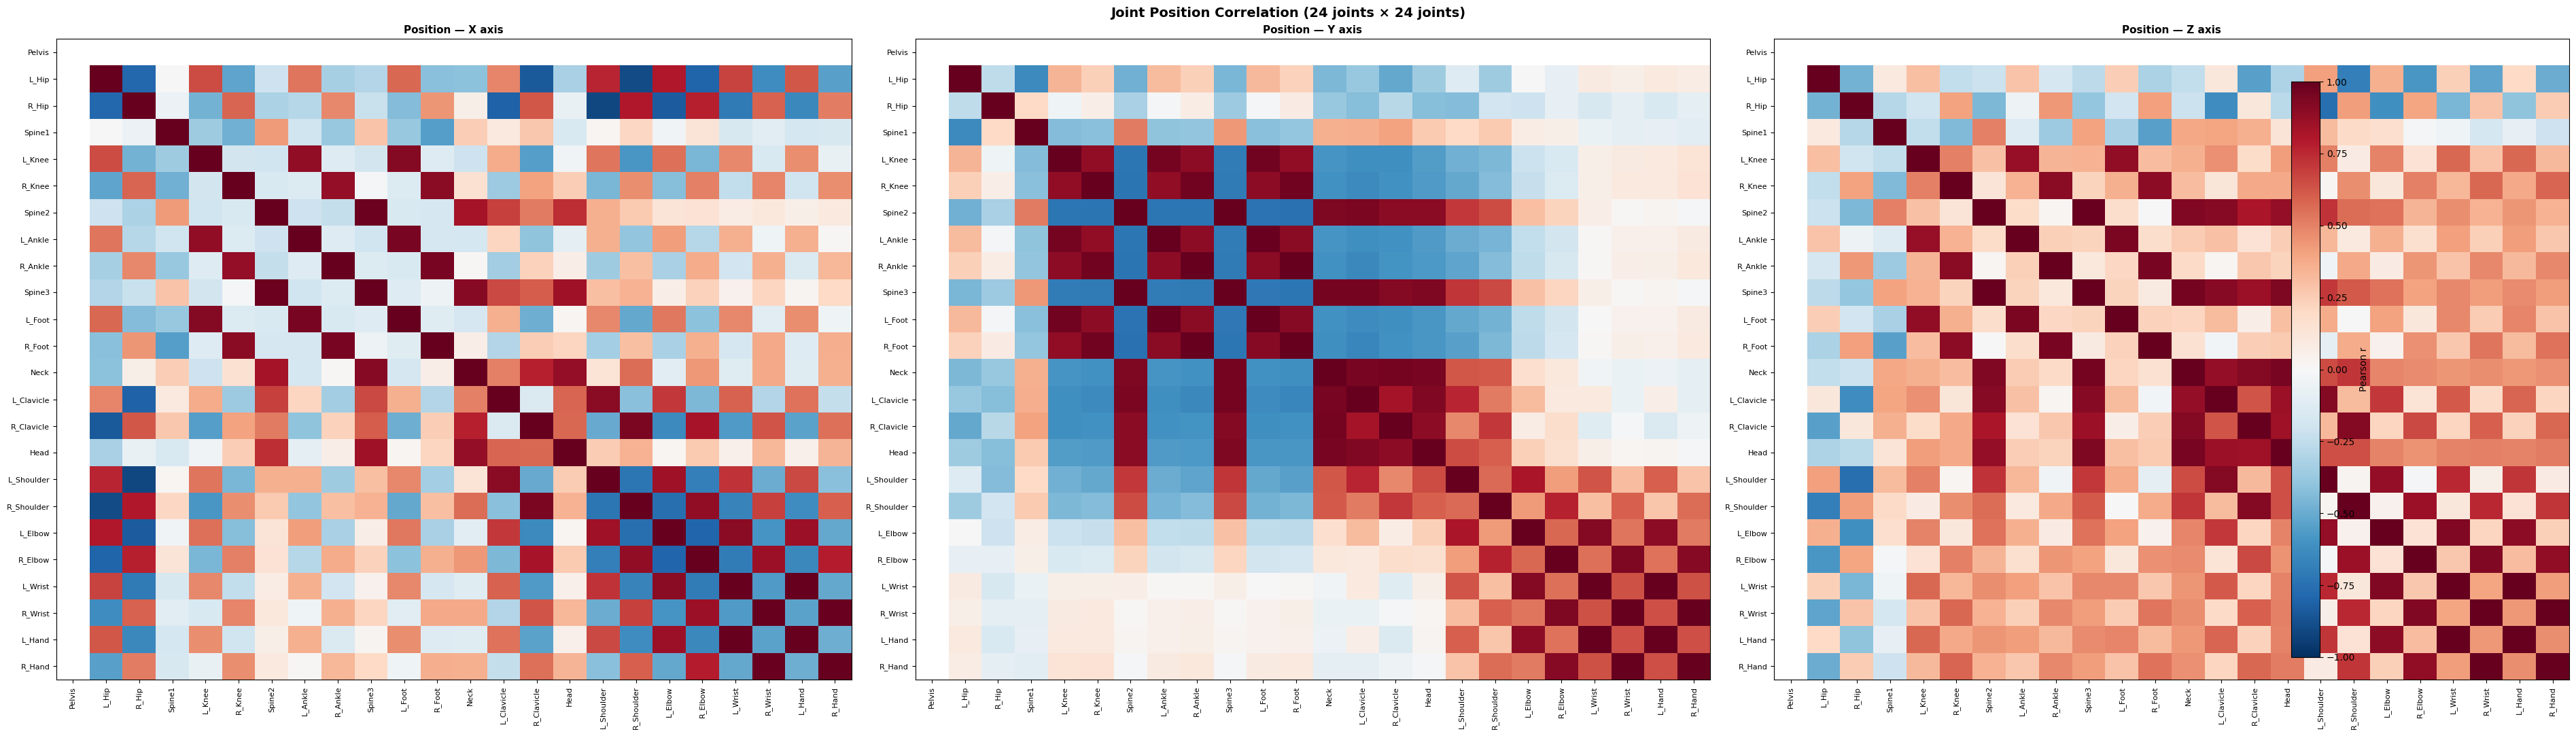

In [13]:
AXES = ['X', 'Y', 'Z']

fig, axes = plt.subplots(1, 3, figsize=(38, 11))
fig.suptitle('Joint Position Correlation (24 joints × 24 joints)', fontsize=14, fontweight='bold')

pos_corr = []
for ax_idx, (ax, axis_name) in enumerate(zip(axes, AXES)):
    # pos[:, :, ax_idx] -> (N, 24) — one column per joint
    mat = np.corrcoef(pos[:, :, ax_idx].T)   # (24, 24)
    pos_corr.append(mat)
    im = plot_corr(mat, f'Position — {axis_name} axis', ax=ax)

plt.colorbar(im, ax=axes, fraction=0.015, pad=0.02, label='Pearson r')
plt.tight_layout()
plt.show()

### 5.1  Average Position Correlation (mean over X, Y, Z)

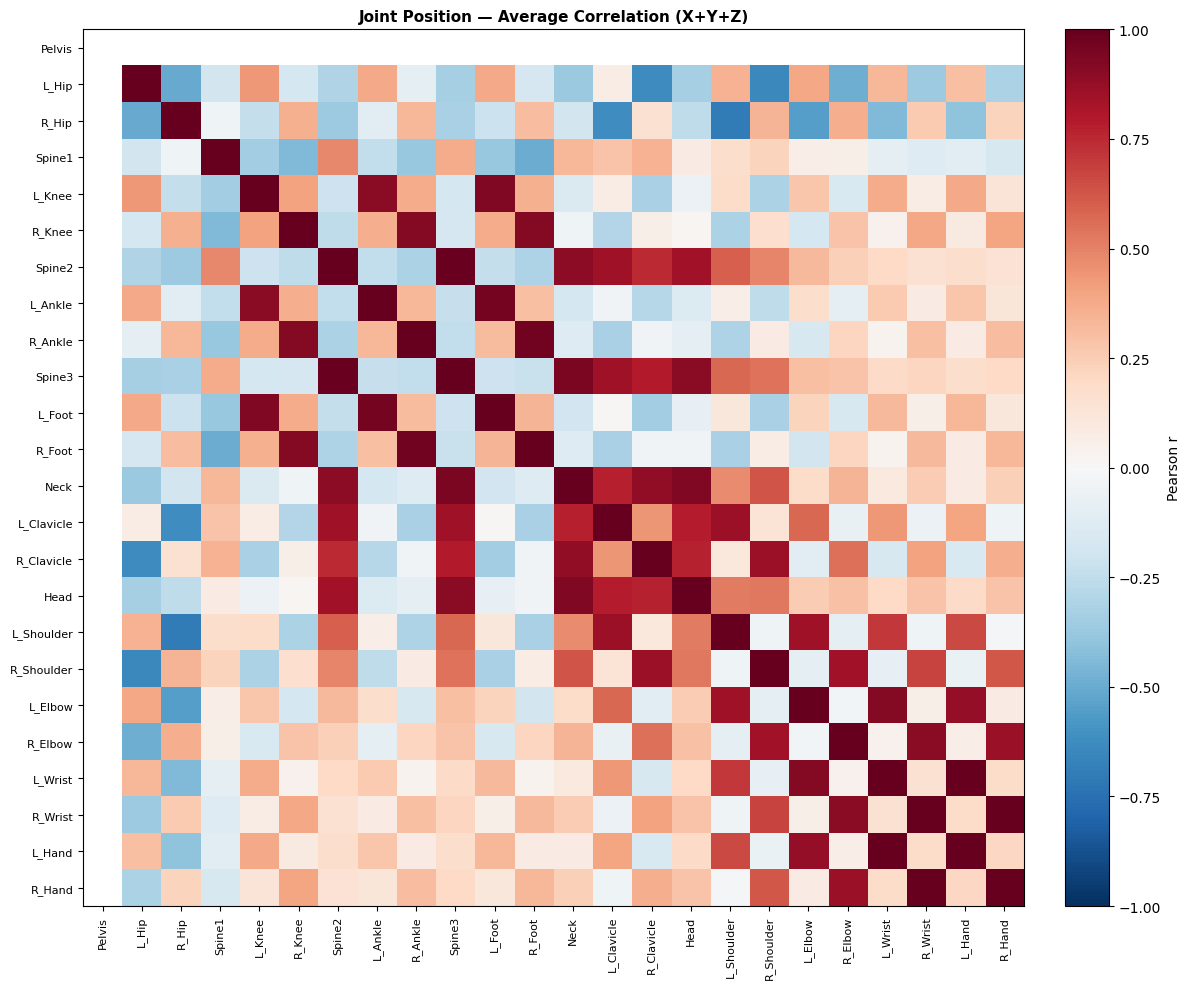

In [14]:
avg_pos_corr = np.mean(np.stack(pos_corr), axis=0)   # (24, 24)
plot_corr(avg_pos_corr, 'Joint Position — Average Correlation (X+Y+Z)')

## 6  Joint Velocity Correlation

/opt/anaconda3/envs/ap_env/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/ap_env/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/anaconda3/envs/ap_env/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/ap_env/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/anaconda3/envs/ap_env/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/ap_env/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/var/folders/b9/

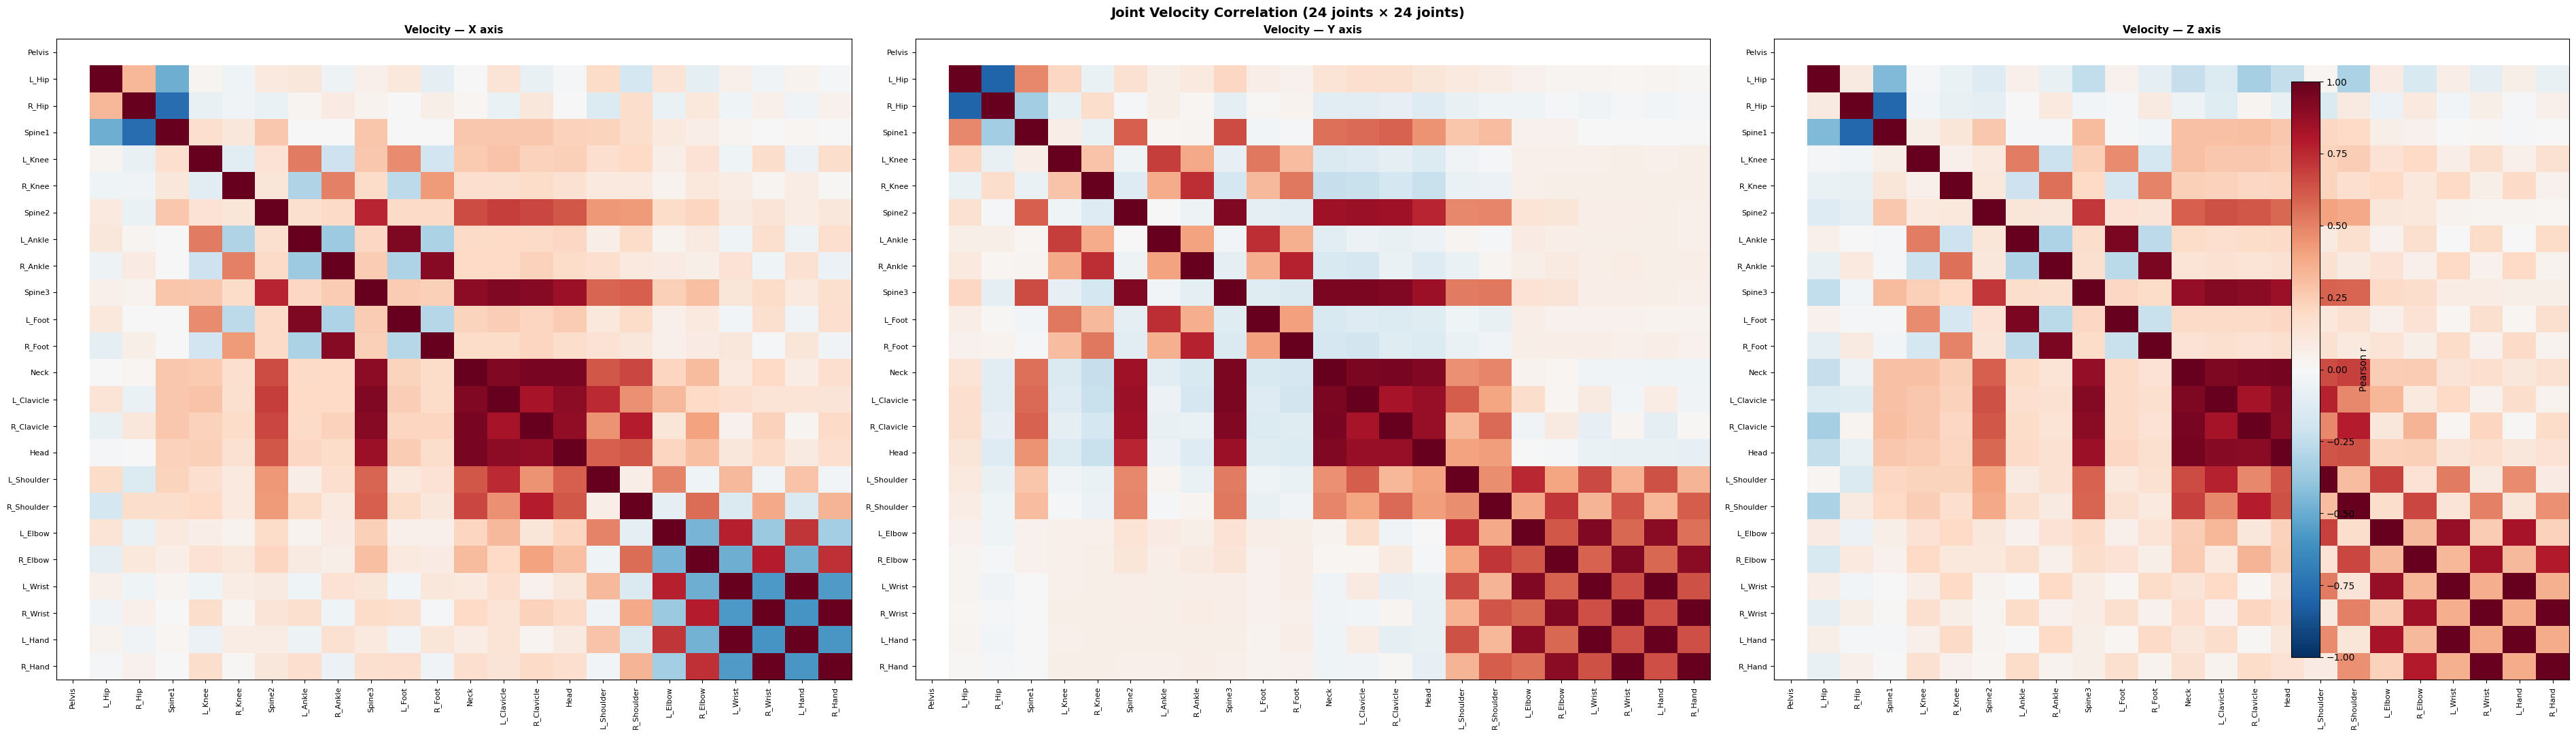

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(38, 11))
fig.suptitle('Joint Velocity Correlation (24 joints × 24 joints)', fontsize=14, fontweight='bold')

vel_corr = []
for ax_idx, (ax, axis_name) in enumerate(zip(axes, AXES)):
    mat = np.corrcoef(vel[:, :, ax_idx].T)
    vel_corr.append(mat)
    im = plot_corr(mat, f'Velocity — {axis_name} axis', ax=ax)

plt.colorbar(im, ax=axes, fraction=0.015, pad=0.02, label='Pearson r')
plt.tight_layout()
plt.show()

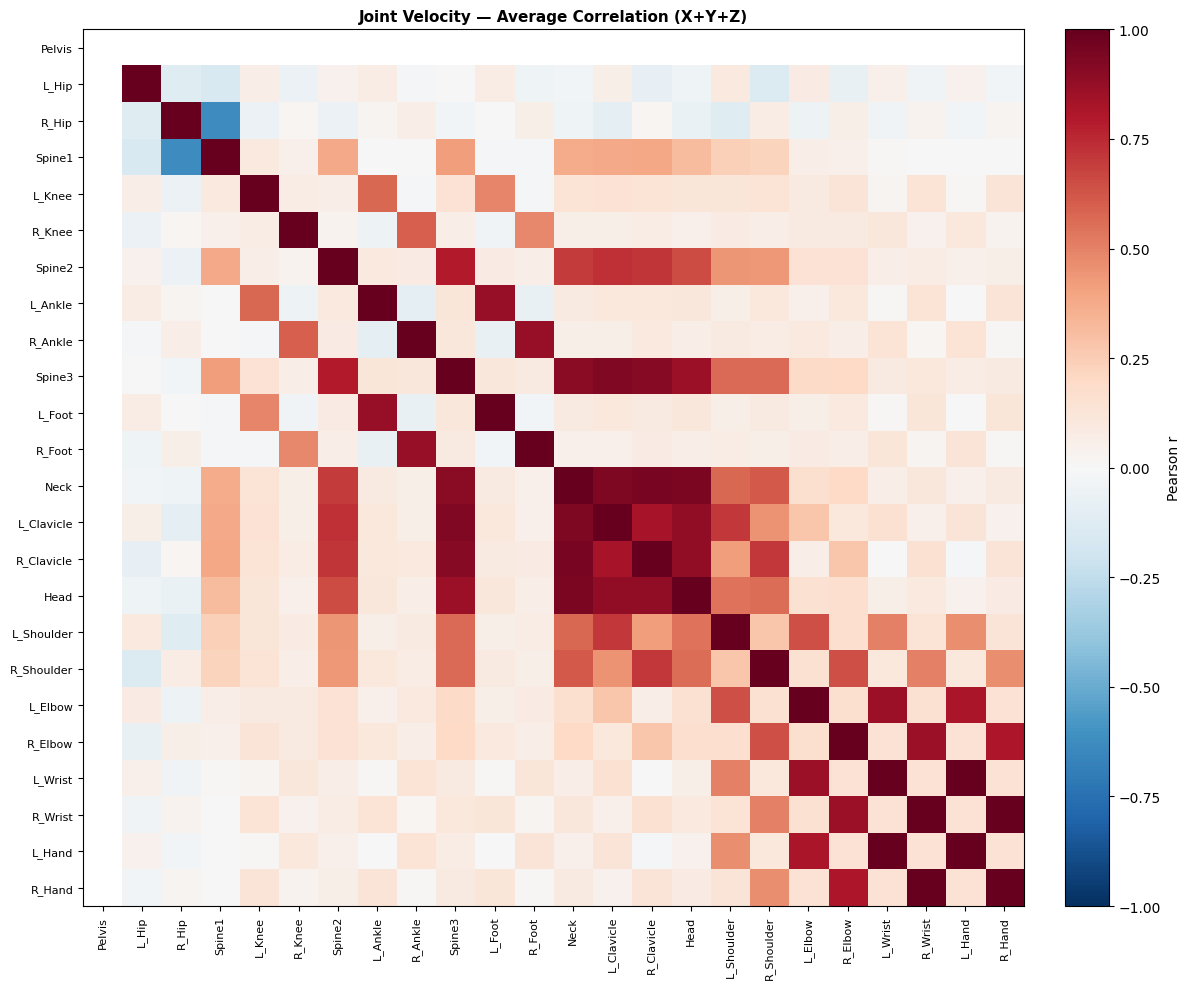

In [16]:
avg_vel_corr = np.mean(np.stack(vel_corr), axis=0)
plot_corr(avg_vel_corr, 'Joint Velocity — Average Correlation (X+Y+Z)')

## 7  Virtual IMU (vIMU) Correlation

The vIMU tensor has 9 channels per joint (3 acceleration + 3 gyroscope + 3 orientation).

/opt/anaconda3/envs/ap_env/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/ap_env/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/anaconda3/envs/ap_env/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/ap_env/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/anaconda3/envs/ap_env/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/envs/ap_env/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/var/folders/b9/

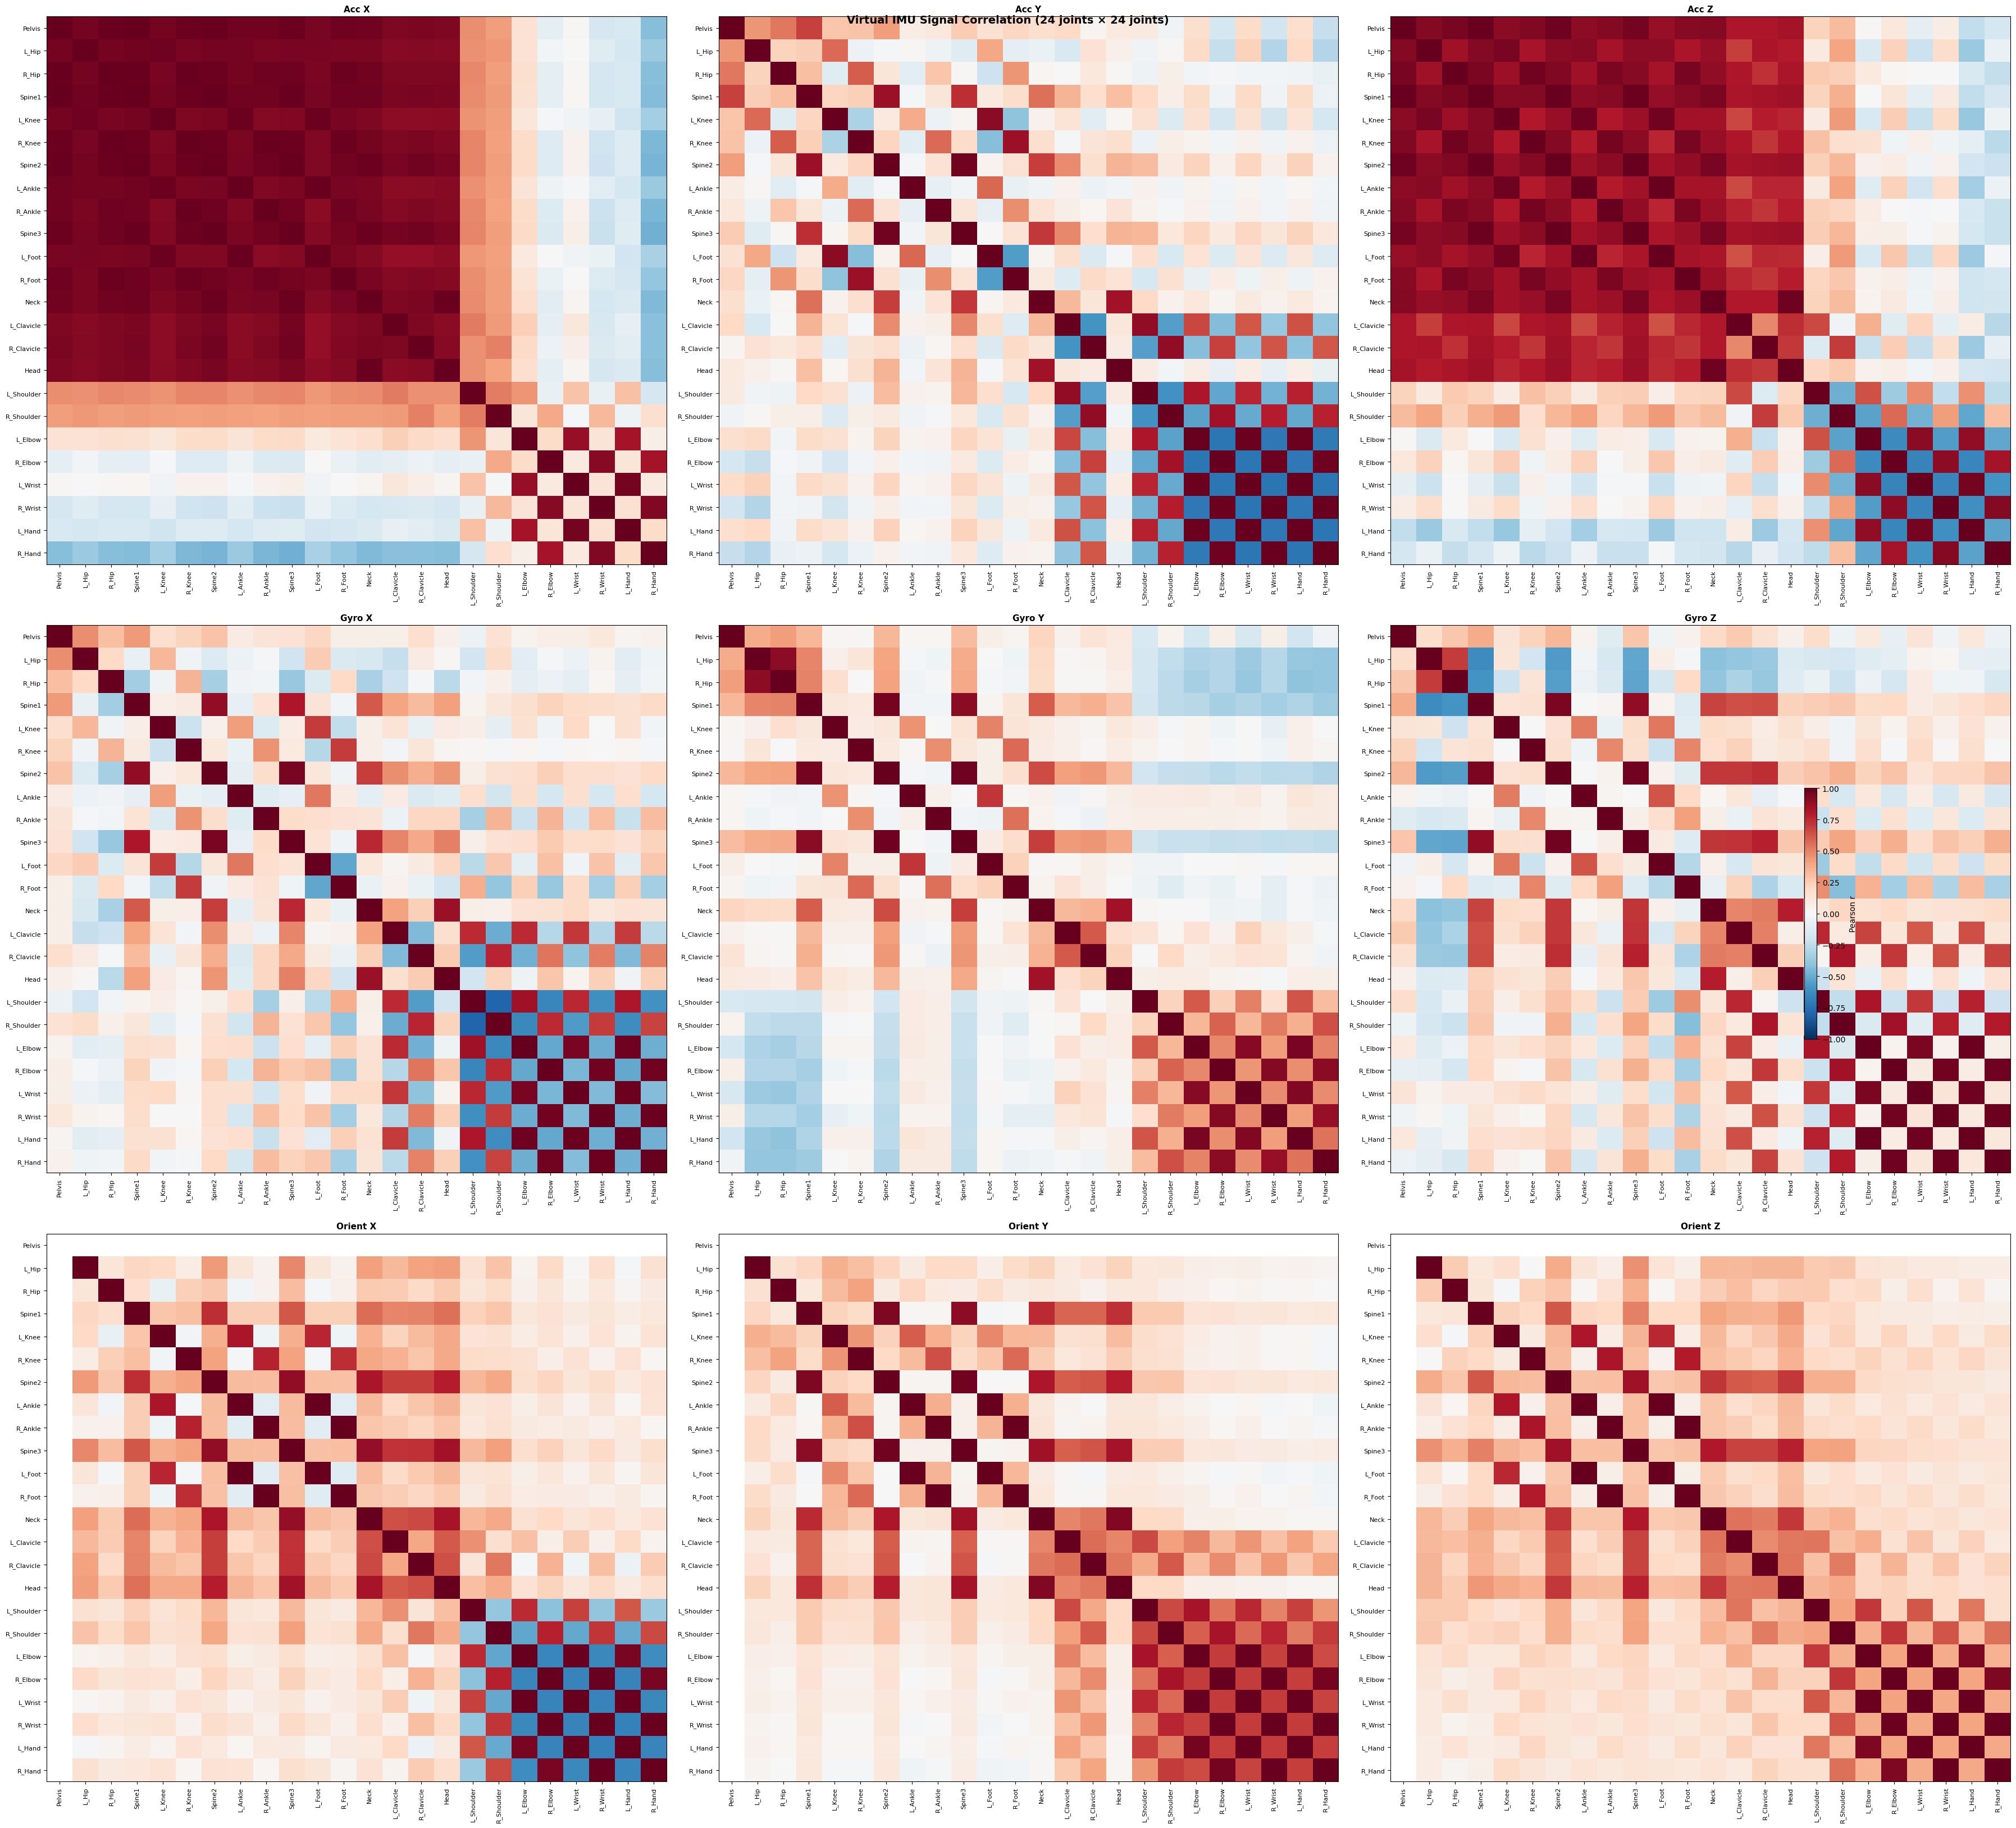

In [17]:
VIMU_CHANNELS = [
    'Acc X', 'Acc Y', 'Acc Z',
    'Gyro X', 'Gyro Y', 'Gyro Z',
    'Orient X', 'Orient Y', 'Orient Z',
]

# Per-channel 24×24 correlation
fig, axes = plt.subplots(3, 3, figsize=(36, 33))
fig.suptitle('Virtual IMU Signal Correlation (24 joints × 24 joints)', fontsize=14, fontweight='bold')

vimu_corr = []
for ch, (ax, ch_name) in enumerate(zip(axes.flat, VIMU_CHANNELS)):
    mat = np.corrcoef(vimu[:, :, ch].T)
    vimu_corr.append(mat)
    im = plot_corr(mat, ch_name, ax=ax)

plt.colorbar(im, ax=axes, fraction=0.008, pad=0.02, label='Pearson r')
plt.tight_layout()
plt.show()

### 7.1  Accelerometer Average Correlation

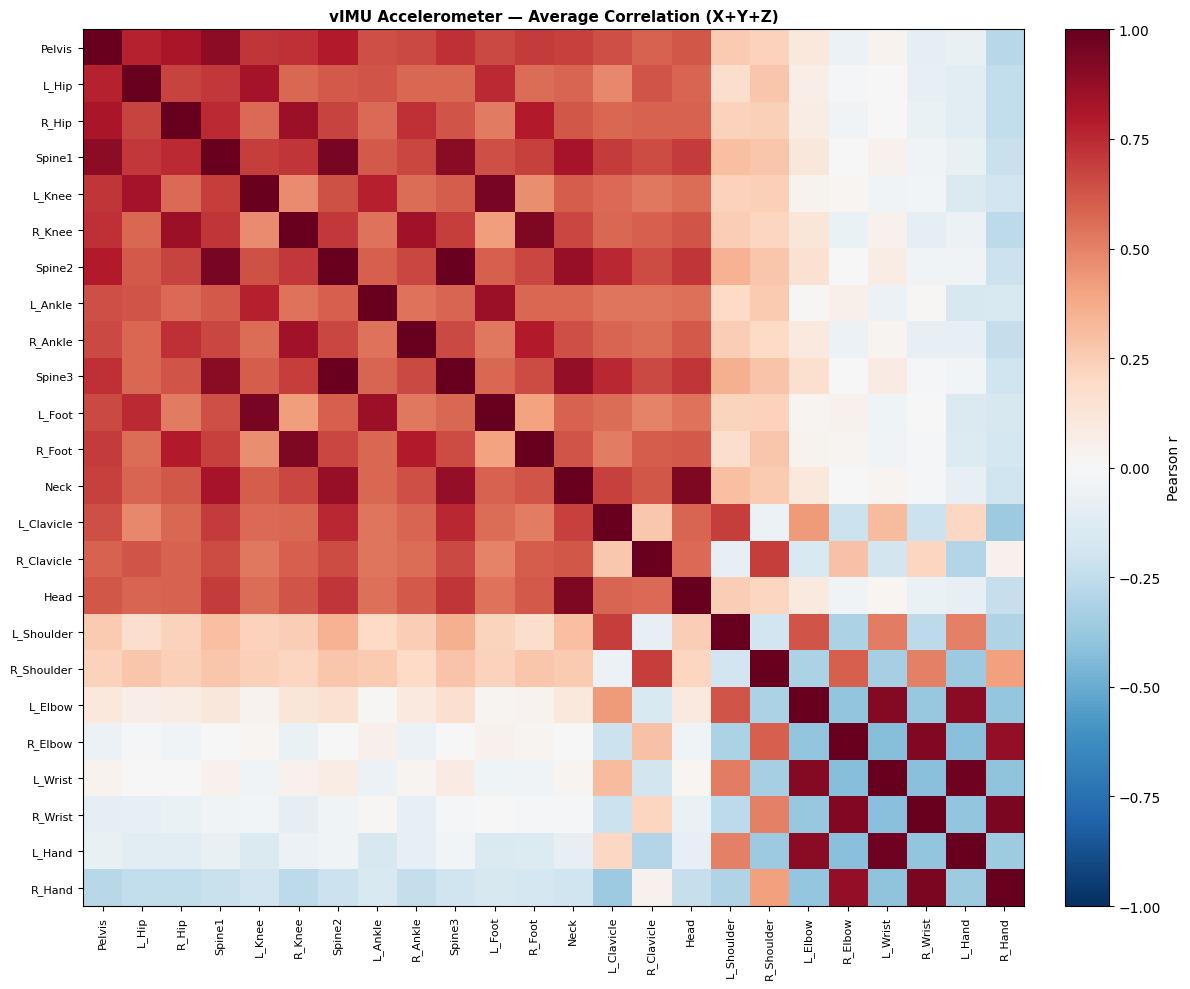

In [18]:
avg_acc_corr = np.mean(np.stack(vimu_corr[:3]), axis=0)
plot_corr(avg_acc_corr, 'vIMU Accelerometer — Average Correlation (X+Y+Z)')

### 7.2  Gyroscope Average Correlation

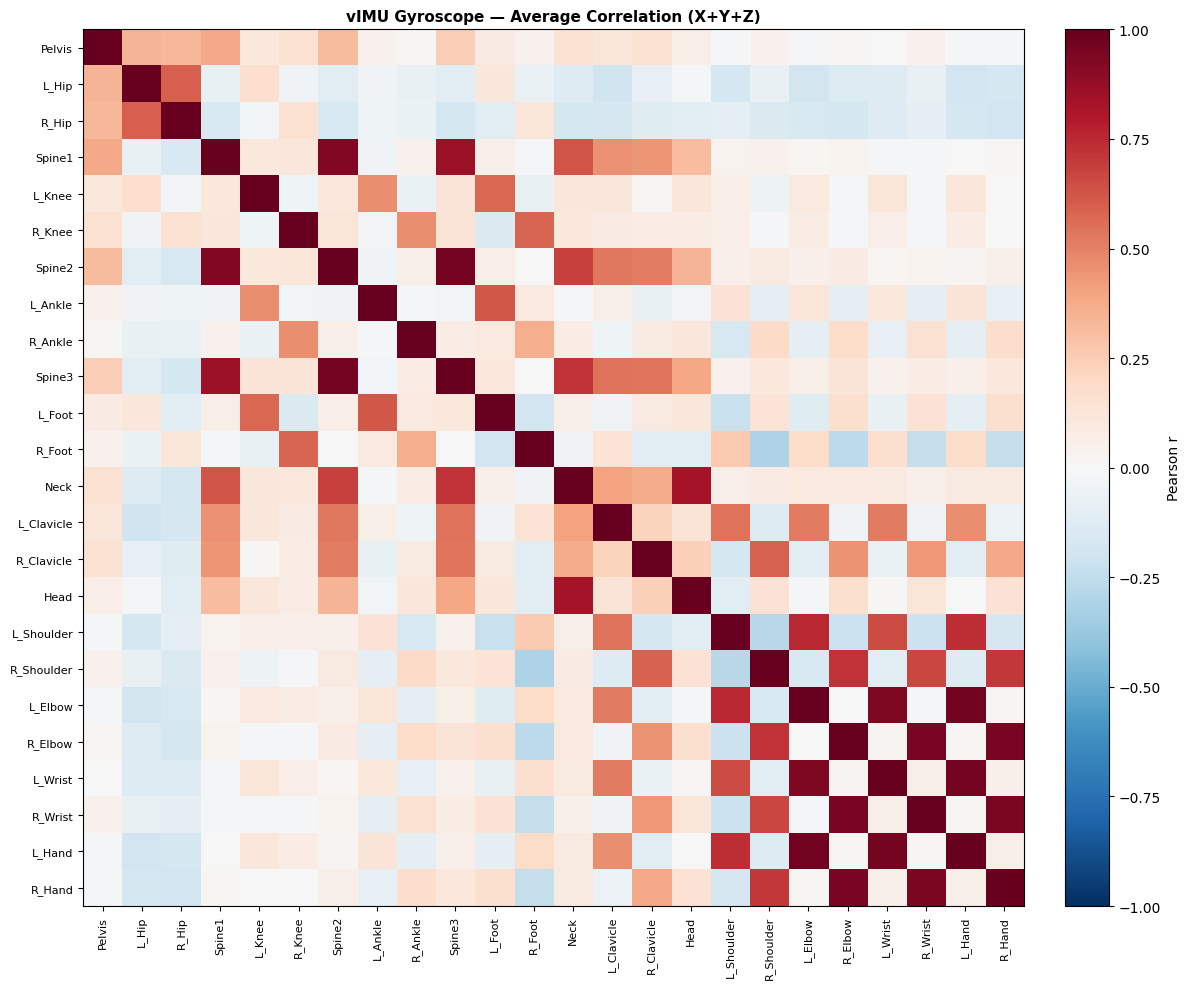

In [19]:
avg_gyro_corr = np.mean(np.stack(vimu_corr[3:6]), axis=0)
plot_corr(avg_gyro_corr, 'vIMU Gyroscope — Average Correlation (X+Y+Z)')

### 7.3  Orientation Average Correlation

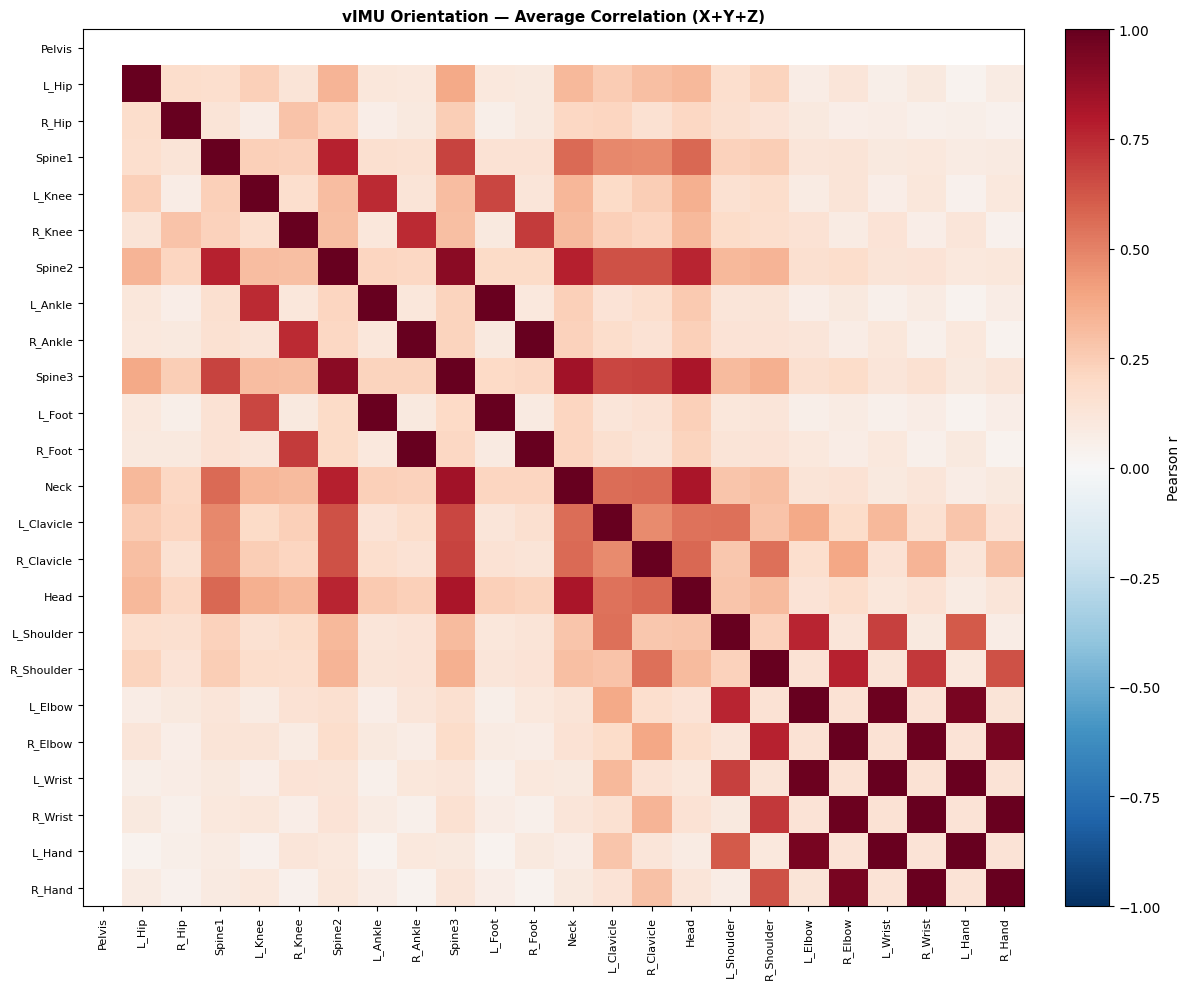

In [20]:
avg_ori_corr = np.mean(np.stack(vimu_corr[6:9]), axis=0)
plot_corr(avg_ori_corr, 'vIMU Orientation — Average Correlation (X+Y+Z)')

## 8  Side-by-Side Summary: Position vs Velocity vs vIMU

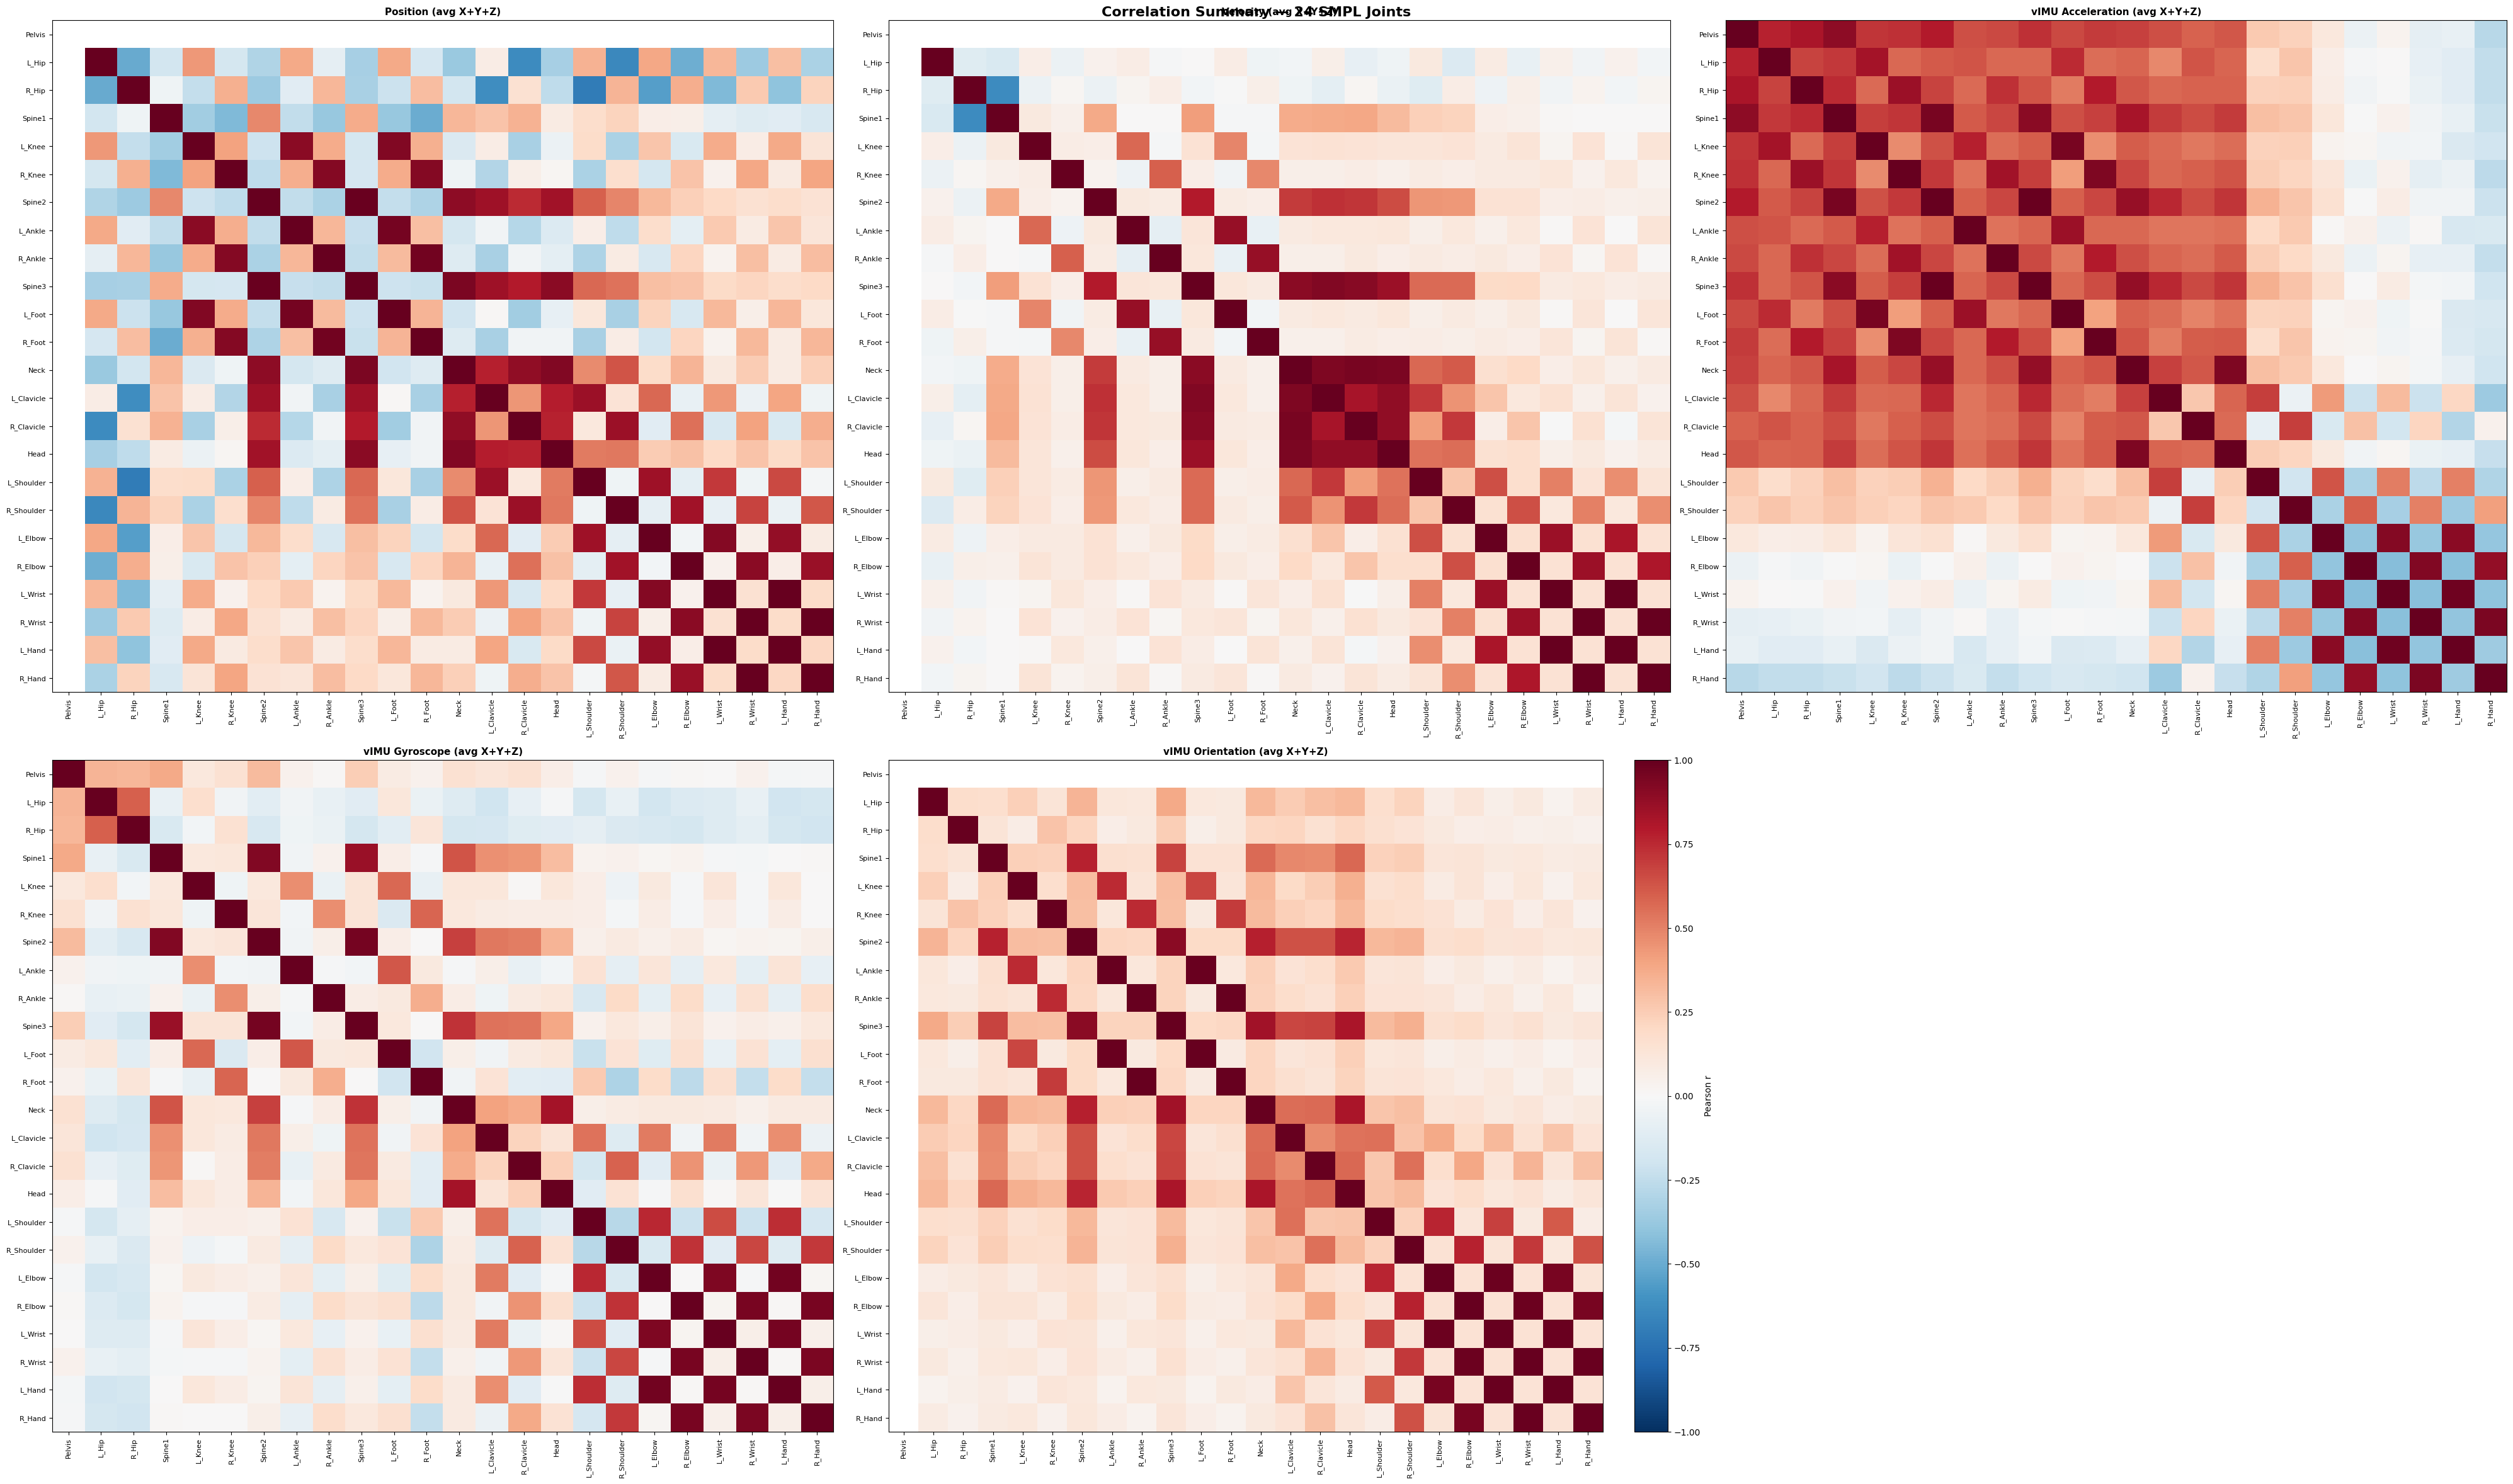

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(40, 24))
fig.suptitle('Correlation Summary — 24 SMPL Joints', fontsize=16, fontweight='bold')

pairs = [
    (avg_pos_corr,  'Position (avg X+Y+Z)',         axes[0, 0]),
    (avg_vel_corr,  'Velocity (avg X+Y+Z)',          axes[0, 1]),
    (avg_acc_corr,  'vIMU Acceleration (avg X+Y+Z)', axes[0, 2]),
    (avg_gyro_corr, 'vIMU Gyroscope (avg X+Y+Z)',    axes[1, 0]),
    (avg_ori_corr,  'vIMU Orientation (avg X+Y+Z)',  axes[1, 1]),
]

for mat, title, ax in pairs:
    im = plot_corr(mat, title, ax=ax)

# hide unused subplot
axes[1, 2].axis('off')

plt.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04, label='Pearson r')
plt.tight_layout()
plt.show()

## 9  Top Correlated Joint Pairs

In [22]:
def top_pairs(corr_mat, name, n=10):
    """Print the n highest off-diagonal absolute correlations."""
    rows, cols = np.triu_indices(N_JOINTS, k=1)
    vals = corr_mat[rows, cols]
    order = np.argsort(np.abs(vals))[::-1][:n]
    print(f"\n{'='*55}")
    print(f"  Top {n} joint pairs — {name}")
    print(f"{'='*55}")
    print(f"  {'Joint A':<14} {'Joint B':<14} {'r':>7}")
    print(f"  {'-'*14} {'-'*14} {'-'*7}")
    for idx in order:
        i, j = rows[idx], cols[idx]
        print(f"  {JOINT_NAMES[i]:<14} {JOINT_NAMES[j]:<14} {vals[idx]:+.4f}")

top_pairs(avg_pos_corr,  'Position (avg)')
top_pairs(avg_vel_corr,  'Velocity (avg)')
top_pairs(avg_acc_corr,  'vIMU Acc (avg)')
top_pairs(avg_gyro_corr, 'vIMU Gyro (avg)')
top_pairs(avg_ori_corr,  'vIMU Orient (avg)')


  Top 10 joint pairs — Position (avg)
  Joint A        Joint B              r
  -------------- -------------- -------
  Pelvis         L_Hip          +nan
  Pelvis         Spine3         +nan
  Pelvis         L_Wrist        +nan
  Pelvis         R_Hand         +nan
  Pelvis         R_Elbow        +nan
  Pelvis         L_Elbow        +nan
  Pelvis         R_Shoulder     +nan
  Pelvis         L_Shoulder     +nan
  Pelvis         Head           +nan
  Pelvis         R_Clavicle     +nan

  Top 10 joint pairs — Velocity (avg)
  Joint A        Joint B              r
  -------------- -------------- -------
  Pelvis         L_Hip          +nan
  Pelvis         R_Ankle        +nan
  Pelvis         R_Hand         +nan
  Pelvis         L_Hand         +nan
  Pelvis         R_Wrist        +nan
  Pelvis         L_Wrist        +nan
  Pelvis         R_Elbow        +nan
  Pelvis         R_Shoulder     +nan
  Pelvis         L_Shoulder     +nan
  Pelvis         Head           +nan

  Top 10 joint pairs 

## 10  Per-Joint Statistics

In [23]:
# Mean absolute correlation each joint has with all others
def joint_connectivity(corr_mat):
    mask = ~np.eye(N_JOINTS, dtype=bool)
    return np.abs(corr_mat)[mask].reshape(N_JOINTS, N_JOINTS - 1).mean(axis=1)

conn_pos  = joint_connectivity(avg_pos_corr)
conn_vel  = joint_connectivity(avg_vel_corr)
conn_acc  = joint_connectivity(avg_acc_corr)
conn_gyro = joint_connectivity(avg_gyro_corr)

df_conn = pd.DataFrame({
    'Joint':    JOINT_NAMES,
    'Position': conn_pos,
    'Velocity': conn_vel,
    'vIMU Acc': conn_acc,
    'vIMU Gyro':conn_gyro,
}).set_index('Joint').round(4)

print('Mean absolute correlation per joint with all others:')
display(df_conn.style.background_gradient(cmap='YlOrRd', axis=0))

Mean absolute correlation per joint with all others:


/opt/anaconda3/envs/ap_env/lib/python3.11/site-packages/pandas/io/formats/style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/opt/anaconda3/envs/ap_env/lib/python3.11/site-packages/pandas/io/formats/style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,Position,Velocity,vIMU Acc,vIMU Gyro
Joint,,,,
Pelvis,nan,nan,0.512600,0.117400
L_Hip,nan,nan,0.456800,0.142500
R_Hip,nan,nan,0.476200,0.160000
Spine1,nan,nan,0.527900,0.207700
L_Knee,nan,nan,0.453300,0.117200
R_Knee,nan,nan,0.479900,0.115000
Spine2,nan,nan,0.522800,0.232600
L_Ankle,nan,nan,0.435400,0.107800
R_Ankle,nan,nan,0.462900,0.121800
